## Manual MFCC / Cepstrum Engine
Implementing full pipeline from scratch — pre-emphasis → framing → windowing → FFT → mel filterbank → log → DCT

### 1. Imports & Load Audio

In [1]:
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt

file = "data/heisenberg.mp3"

sig, sr = sf.read(file)

if len(sig.shape) > 1:
    sig = sig.mean(axis=1)

sig = sig.astype(np.float64)

print("Sample rate :", sr)
print("Total samples:", len(sig))
print("Duration (s) :", round(len(sig)/sr, 3))

Sample rate : 32000
Total samples: 493056
Duration (s) : 15.408


### 2. Pre-emphasis
Boosts high frequencies. Filter: y[n] = x[n] - α·x[n-1]

In [2]:
alpha = 0.97

emph = np.append(sig[0], sig[1:] - alpha * sig[:-1])

### 3. Framing
25 ms frames with 10 ms hop

In [3]:
frame_ms = 25.0
step_ms  = 10.0

frame_len = int(frame_ms * sr / 1000)
step_len  = int(step_ms  * sr / 1000)

num_frames = int((len(emph) - frame_len) / step_len) + 1

pad_len = num_frames * step_len + frame_len
padded = np.zeros(pad_len)
padded[:len(emph)] = emph

frames = []
for i in range(num_frames):
    start = i * step_len
    frames.append(padded[start : start + frame_len])

frames = np.array(frames)
print("Frames shape:", frames.shape)

Frames shape: (1539, 800)


### 4. Windowing — Hamming

In [4]:
win    = np.hamming(frame_len)
frames = frames * win

### 5. FFT → Power Spectrum

In [5]:
NFFT = 512

mag      = np.abs(np.fft.rfft(frames, NFFT))
pow_spec = (1.0 / NFFT) * (mag ** 2)

### 6. Mel Filterbank  (40 triangular filters)

In [6]:
nfilt = 40

low_mel  = 0.0
high_mel = 2595.0 * np.log10(1.0 + (sr / 2.0) / 700.0)

mel_pts = np.linspace(low_mel, high_mel, nfilt + 2)
hz_pts  = 700.0 * (10.0 ** (mel_pts / 2595.0) - 1.0)

bins = np.floor((NFFT + 1) * hz_pts / sr).astype(int)

fbank = np.zeros((nfilt, NFFT // 2 + 1))

for m in range(1, nfilt + 1):
    f1 = bins[m - 1]
    f2 = bins[m]
    f3 = bins[m + 1]

    for k in range(f1, f2):
        fbank[m - 1, k] = (k - f1) / (f2 - f1 + 1e-8)

    for k in range(f2, f3):
        fbank[m - 1, k] = (f3 - k) / (f3 - f2 + 1e-8)

### 7. Log compression

In [7]:
mel_energy = np.dot(pow_spec, fbank.T)
mel_energy = np.where(mel_energy == 0, np.finfo(float).eps, mel_energy)
log_mel    = np.log(mel_energy)

### 8. DCT → 13 MFCCs

In [8]:
num_ceps = 13
N = log_mel.shape[1]

mfcc = np.zeros((log_mel.shape[0], num_ceps))

for k in range(num_ceps):
    for n in range(N):
        mfcc[:, k] += log_mel[:, n] * np.cos(np.pi * k * (n + 0.5) / N)

print("MFCC shape:", mfcc.shape)

MFCC shape: (1539, 13)


### 9. Real Cepstrum

In [9]:
def real_cepstrum(frame, nfft=512):
    spec  = np.fft.rfft(frame, n=nfft)
    log_s = np.log(np.abs(spec) + 1e-10)
    sym   = np.concatenate([log_s, log_s[-2:0:-1]])
    return np.real(np.fft.ifft(sym))

cepstrum = np.array([real_cepstrum(f, NFFT) for f in frames])
print("Cepstrum shape:", cepstrum.shape)

Cepstrum shape: (1539, 512)


### 10. Visualisation

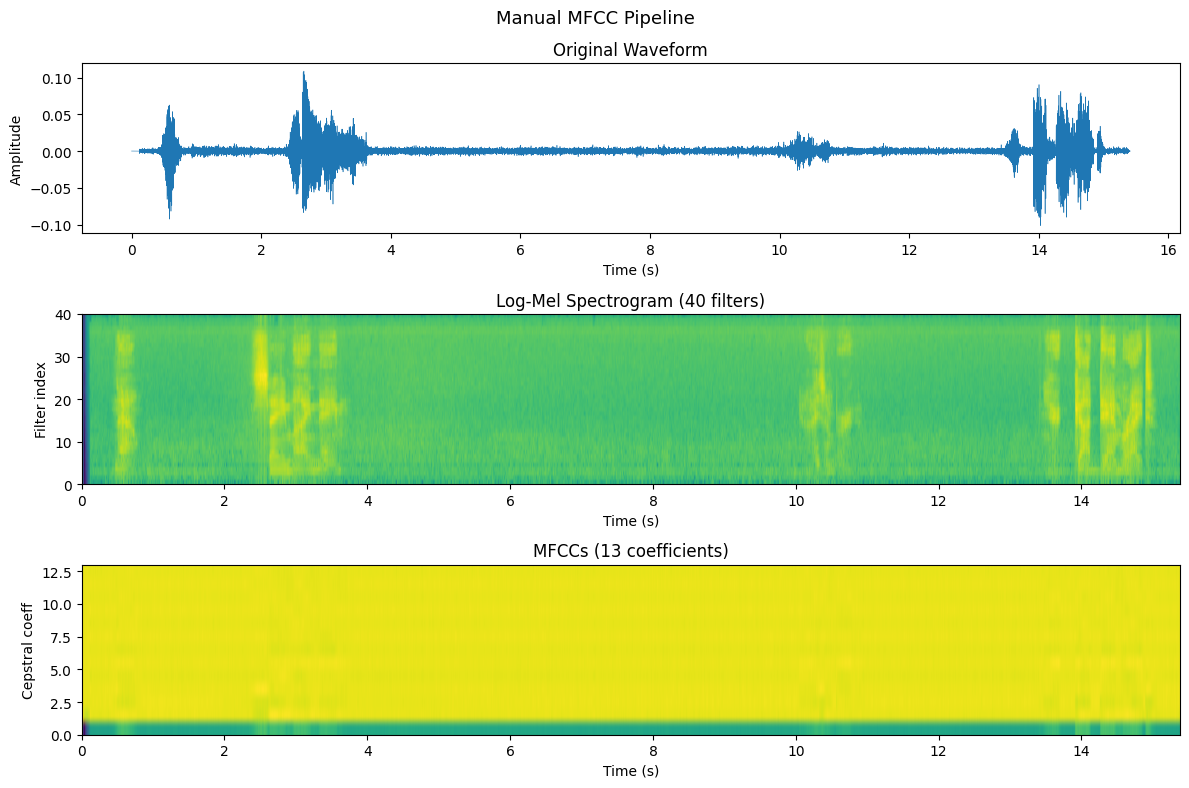

In [10]:
t_wav  = np.arange(len(sig)) / sr
t_feat = np.arange(num_frames) * (step_ms / 1000.0)

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

axes[0].plot(t_wav, sig, lw=0.4)
axes[0].set_title("Original Waveform")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")

axes[1].imshow(log_mel.T, aspect='auto', origin='lower',
               extent=[t_feat[0], t_feat[-1], 0, nfilt])
axes[1].set_title("Log-Mel Spectrogram (40 filters)")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Filter index")

axes[2].imshow(mfcc.T, aspect='auto', origin='lower',
               extent=[t_feat[0], t_feat[-1], 0, num_ceps])
axes[2].set_title("MFCCs (13 coefficients)")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Cepstral coeff")

plt.suptitle("Manual MFCC Pipeline", fontsize=13)
plt.tight_layout()
plt.savefig("mfcc_output.png", dpi=150)
plt.show()